# 牛牛战法 Round 64：主升确认加仓与高潮减仓

## tl;dr

- 6.25% 只作为酝酿试仓上限；原试仓/启动仓只有在浮盈至少 2%、主线确认、生命周期仍为主升且个股仍是强势领涨时才加仓。
- 20% 阶段上限配合首次非亏损高潮减仓 1/3，使四个开发窗组合收益从 13.64% 提高到 15.38%，胜率仍为 59.29%。
- 最差回撤从 -1.06% 扩大到 -2.01%，平均暴露仅从 9.94% 提高到 10.08%；四窗只有 1 次合格升级，30% 上限没有新增收益。

## Context & Methods

分析读取 `scripts/research_niuone_walk_forward.py` 生成的两个精确回放结果：生产 v19 对比与 Round 64 上限敏感性。四个互斥开发窗用于汇总；`recent` 只作重叠诊断，不参与生产选择；保留区间不打开。所有仓位变化均在信号日收盘后判定、下一交易日开盘执行，并继续经过现金、整手、T+1、涨跌停、单票/主题/组合风险和费用滑点约束。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

PRODUCTION_RESULT = Path('/tmp/niuone-production-v19-markup-scale-climax.json')
SENSITIVITY_RESULT = Path('/tmp/niuone-round64-markup-only-scale-reduce.json')
DEVELOPMENT_WINDOWS = ['old_sealed', 'train_a', 'train_b', 'validation']
ALL_WINDOWS = DEVELOPMENT_WINDOWS + ['recent']

for result_path in (PRODUCTION_RESULT, SENSITIVITY_RESULT):
    if not result_path.exists():
        raise FileNotFoundError(f'先用 scripts/research_niuone_walk_forward.py 生成 {result_path}')

production = json.loads(PRODUCTION_RESULT.read_text(encoding='utf-8'))
sensitivity = json.loads(SENSITIVITY_RESULT.read_text(encoding='utf-8'))

## Data

源结果覆盖 4,997 只参考股票、4,915 只成功行情和 3,033 只有效行情。行业标签按历史生效日恢复；成员与名称仍使用当前快照。下面只抽取策略判断所需的窗口收益、胜率、回撤、暴露和加仓计数。

In [2]:
candidate_labels = {
    'frozen_production_default': 'v18 基线',
    'production_v19_markup_scale_climax_reduce': 'v19 主升加仓+高潮减仓',
}
window_labels = {
    'old_sealed': '旧封存', 'train_a': '训练 A', 'train_b': '训练 B',
    'validation': '验证', 'recent': '近期诊断',
}

window_rows = []
for candidate_id, label in candidate_labels.items():
    candidate = production['candidates'][candidate_id]
    for window_name in ALL_WINDOWS:
        window = candidate['windows'][window_name]
        stats = window['statistics']
        window_rows.append({
            '策略': label,
            '窗口': window_labels[window_name],
            '交易数': stats['trade_count'],
            '胜率(%)': stats['win_rate_pct'],
            '组合收益(%)': stats['portfolio_return_pct'],
            '最大回撤(%)': stats['max_drawdown_pct'],
            '平均暴露(%)': stats['average_exposure_pct'],
            '最大暴露(%)': stats['max_exposure_pct'],
            '加仓单数': stats['add_order_count'],
            '生命周期升级数': window['lifecycle']['upgraded_trade_count'],
        })
window_df = pd.DataFrame(window_rows)
print(window_df.to_string(index=False))

           策略   窗口  交易数   胜率(%)  组合收益(%)  最大回撤(%)  平均暴露(%)  最大暴露(%)  加仓单数  生命周期升级数
       v18 基线  旧封存   32 62.5000   3.0426  -1.0616  10.6725  35.1582     1        0
       v18 基线 训练 A   30 63.3333   4.7625  -1.0385   9.8839  30.4752     0        0
       v18 基线 训练 B   41 60.9756   3.4030  -0.9177  10.1081  36.3078     0        0
       v18 基线   验证   37 51.3514   1.8069  -0.8539   9.0865  24.5143     0        0
       v18 基线 近期诊断   15 60.0000  -0.3322  -1.3138   5.1436  23.0655     0        0
v19 主升加仓+高潮减仓  旧封存   32 62.5000   4.3380  -2.0145  11.1396  35.3997     2        1
v19 主升加仓+高潮减仓 训练 A   30 63.3333   4.8150  -1.0380   9.9499  30.4752     0        0
v19 主升加仓+高潮减仓 训练 B   41 60.9756   3.5646  -1.0300  10.2136  36.3078     0        0
v19 主升加仓+高潮减仓   验证   37 51.3514   1.8693  -0.8539   9.0172  24.4991     0        0
v19 主升加仓+高潮减仓 近期诊断   15 60.0000  -0.3322  -1.3138   5.1436  23.0655     0        0


## Results

先比较生产候选与基线，再检查 15%/20%/30% 上限是否形成稳定邻域。

           策略  完整交易   胜率(%)  四窗收益连乘(%) 正收益窗口  最差回撤(%)  四窗平均暴露(%)  加仓单数  生命周期升级数
       v18 基线   140 59.2857    13.6405   4/4  -1.0616     9.9378     1        0
v19 主升加仓+高潮减仓   140 59.2857    15.3774   4/4  -2.0145    10.0801     2        1


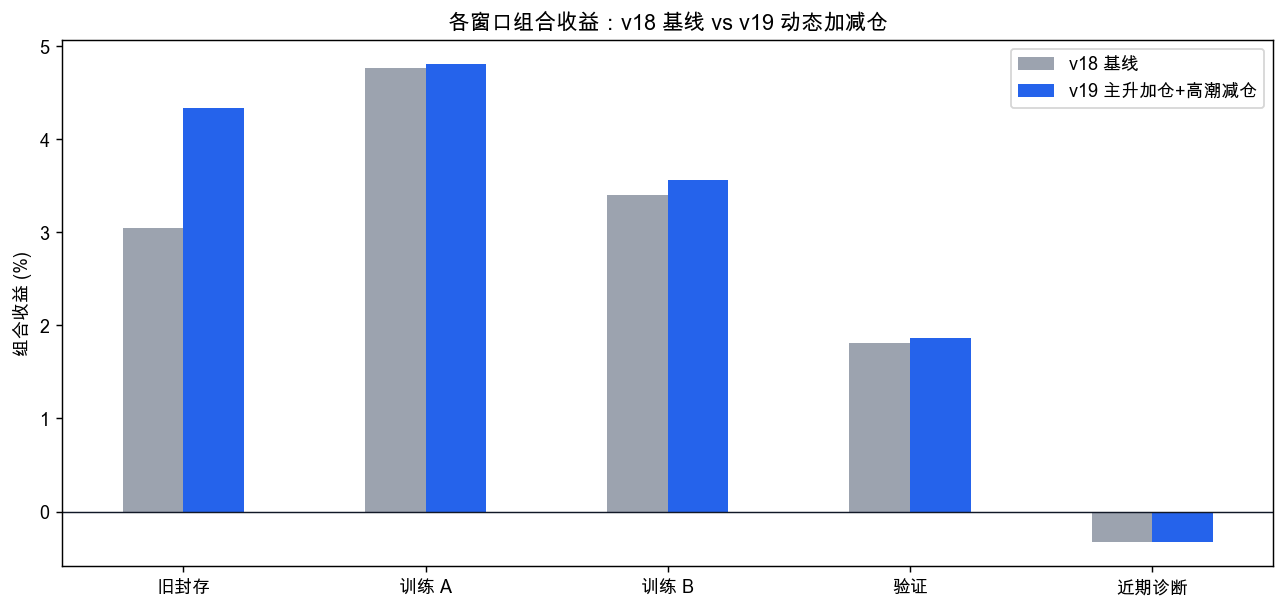

In [3]:
summary_rows = []
for candidate_id, label in candidate_labels.items():
    candidate = production['candidates'][candidate_id]
    aggregate = candidate['development_aggregate']
    dev_windows = [candidate['windows'][name] for name in DEVELOPMENT_WINDOWS]
    summary_rows.append({
        '策略': label,
        '完整交易': aggregate['completed_trade_count'],
        '胜率(%)': aggregate['win_rate_pct'],
        '四窗收益连乘(%)': aggregate['compounded_portfolio_return_pct'],
        '正收益窗口': f"{aggregate['positive_window_count']}/{aggregate['evaluated_window_count']}",
        '最差回撤(%)': aggregate['worst_max_drawdown_pct'],
        '四窗平均暴露(%)': sum(w['statistics']['average_exposure_pct'] for w in dev_windows) / len(dev_windows),
        '加仓单数': sum(w['statistics']['add_order_count'] for w in dev_windows),
        '生命周期升级数': sum(w['lifecycle']['upgraded_trade_count'] for w in dev_windows),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(4).to_string(index=False))

pivot = window_df.pivot(index='窗口', columns='策略', values='组合收益(%)').loc[list(window_labels.values())]
ax = pivot.plot(kind='bar', figsize=(10, 4.8), color=['#9CA3AF', '#2563EB'])
ax.axhline(0, color='#111827', linewidth=0.8)
ax.set_title('各窗口组合收益：v18 基线 vs v19 动态加减仓')
ax.set_ylabel('组合收益 (%)')
ax.set_xlabel('')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()

In [4]:
sensitivity_labels = {
    'frozen_production_default': ('基线', 6.25, False),
    'round64_markup_profit_2_cap_15_climax_33': ('15% + 高潮减 1/3', 15.0, True),
    'round64_markup_profit_2_cap_20_climax_33': ('20% + 高潮减 1/3', 20.0, True),
    'round64_markup_profit_2_cap_30_climax_33': ('30% + 高潮减 1/3', 30.0, True),
}
sensitivity_rows = []
for candidate_id, (label, cap, climax_reduce) in sensitivity_labels.items():
    candidate = sensitivity['candidates'][candidate_id]
    aggregate = candidate['development_aggregate']
    dev_windows = [candidate['windows'][name] for name in DEVELOPMENT_WINDOWS]
    sensitivity_rows.append({
        '候选': label,
        '阶段上限(%)': cap,
        '高潮减仓': climax_reduce,
        '胜率(%)': aggregate['win_rate_pct'],
        '四窗收益连乘(%)': aggregate['compounded_portfolio_return_pct'],
        '最差回撤(%)': aggregate['worst_max_drawdown_pct'],
        '四窗平均暴露(%)': sum(w['statistics']['average_exposure_pct'] for w in dev_windows) / len(dev_windows),
        '生命周期升级数': sum(w['lifecycle']['upgraded_trade_count'] for w in dev_windows),
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df.round(4).to_string(index=False))

           候选  阶段上限(%)  高潮减仓   胜率(%)  四窗收益连乘(%)  最差回撤(%)  四窗平均暴露(%)  生命周期升级数
           基线     6.25 False 59.2857    13.6405  -1.0616     9.9378        0
15% + 高潮减 1/3    15.00  True 59.2857    15.2315  -1.8867    10.0705        1
20% + 高潮减 1/3    20.00  True 59.2857    15.3774  -2.0145    10.0801        1
30% + 高潮减 1/3    30.00  True 59.2857    15.3774  -2.0145    10.0801        1


## Takeaways

1. 生产规则采用 20% 阶段上限，不采用 30%：两者收益、回撤、暴露与升级数完全相同，说明动态风险目标先于 30% 生效。
2. 胜率没有变化，因为这次优化只改变已持仓盈利路径，不改变入口样本；收益提升不能解释为选股准确率提升。
3. 资金利用率仍低的主因是合格主升升级只有 1 次，而不是单票上限仍过紧。继续提高利用率应优先增加可验证主线机会覆盖与并发，不能放宽分歧期加仓。
4. 最差回撤扩大约 0.95 个百分点，近期诊断窗口不变。v19 需要新的严格前向队列与至少 30 笔完整生命周期验证；当前历史结果不是未来收益承诺。